<a href="https://colab.research.google.com/github/ahmedalsufyan/IBM-Applied-Data-Science-Capstone/blob/main/7_Machine_Learning_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 7 Dashboard: Web dashboard containing interactive Dropdowns and Payload Sliders built using Plotly Dash.

# Task 8: Machine Learning Classification Models
**Author:** Ahmed Alsufyan  

### Overview
Standardizing features, performing One-Hot Encoding, splitting data, and tuning ML classification algorithms (Logistic Regression, SVM, Decision Tree, KNN) using GridSearchCV.

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/u

=== Performance Comparison of the Four Models ===
                       Model  Train Accuracy (CV)  Test Accuracy
         Logistic Regression             0.819643       0.833333
Support Vector Machine (SVM)             0.848214       0.833333
   K-Nearest Neighbors (KNN)             0.819643       0.833333
               Decision Tree             0.833929       0.722222


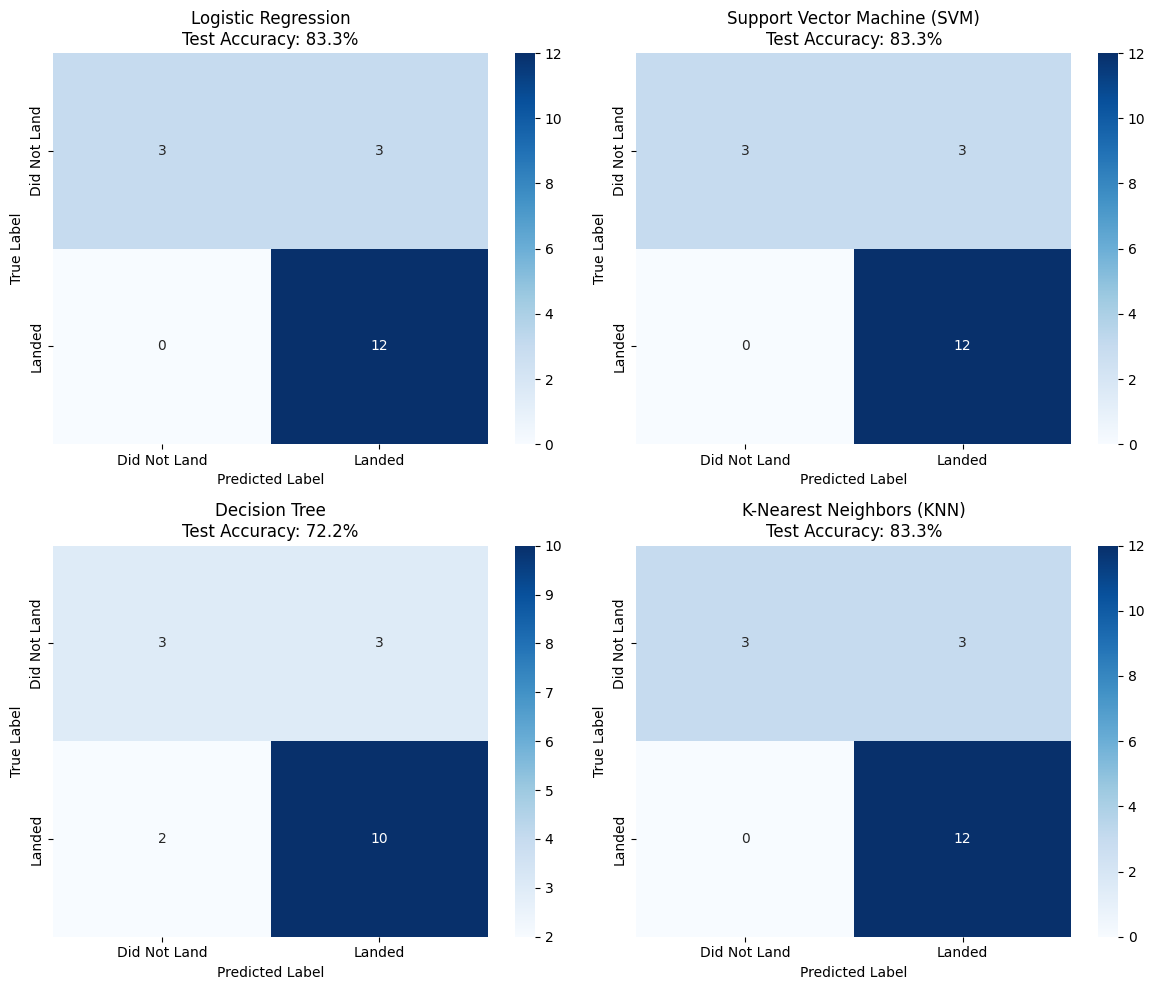

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load data and prepare features
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(dataset_url)

features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights',
              'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block',
              'ReusedCount', 'Serial']]
Y = df['Class'].to_numpy()

# One-Hot Encoding
X = pd.get_dummies(features).astype('float64')

# 2. Split data into 80% training and 20% testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 3. Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Hyperparameter tuning setup for GridSearchCV

parameters_lr = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

parameters_svm = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5)
}

parameters_tree = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2*n for n in range(1, 10)],
    'max_features': ['auto', 'sqrt'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

parameters_knn = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

# Model list for iteration
models = [
    ("Logistic Regression", LogisticRegression(), parameters_lr),
    ("Support Vector Machine (SVM)", SVC(), parameters_svm),
    ("Decision Tree", DecisionTreeClassifier(random_state=2), parameters_tree),
    ("K-Nearest Neighbors (KNN)", KNeighborsClassifier(), parameters_knn)
]

# 5. Train and evaluate each model
model_performance = {}

for name, model, params in models:
    grid = GridSearchCV(model, params, cv=10)
    grid.fit(X_train, Y_train)

    y_pred = grid.predict(X_test)
    test_acc = accuracy_score(Y_test, y_pred)

    model_performance[name] = {
        "Best Model": grid.best_estimator_,
        "Best Params": grid.best_params_,
        "Train Accuracy (CV)": grid.best_score_,
        "Test Accuracy": test_acc,
        "Confusion Matrix": confusion_matrix(Y_test, y_pred)
    }

# 6. Display final performance summary table
results_summary = pd.DataFrame({
    "Model": list(model_performance.keys()),
    "Train Accuracy (CV)": [model_performance[m]["Train Accuracy (CV)"] for m in model_performance],
    "Test Accuracy": [model_performance[m]["Test Accuracy"] for m in model_performance]
}).sort_values(by="Test Accuracy", ascending=False)

print("=== Performance Comparison of the Four Models ===")
print(results_summary.to_string(index=False))

# 7. Plot confusion matrices for all models in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, perf) in enumerate(model_performance.items()):
    sns.heatmap(perf["Confusion Matrix"], annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Did Not Land', 'Landed'],
                yticklabels=['Did Not Land', 'Landed'])
    axes[i].set_title(f"{name}\nTest Accuracy: {perf['Test Accuracy']*100:.1f}%")
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()